In [2]:
# imports
import os
import random
from datetime import timedelta

import numpy as np
import pandas as pd
import polars as pl
import re
from glob import glob

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

import tensorflow as tf
from keras.utils import to_categorical

from numpy.random import default_rng
from sklearn.model_selection import KFold
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    auc,
    precision_recall_curve,
    average_precision_score,
)

import data_preprocessing
from data_integration import combine_data, read_data
import data_models

In [3]:
# function to flatten data
def flatten(subject):
    # converts all sublists to arrays
    array_data = [np.array(x) for x in subject]  
    flattened_data = np.concatenate(array_data, axis=0)
    return flattened_data


## Read data

In [ ]:
"""
    Calls the "read_data()" function from file "data_integration.py"
    Calls the "combine_data()" function from file "data_integration.py"
    Parameter:
    - 1: combines only glucose data
    - 2: combines glucose and dempgraphics
    - 3: combines glucose and heartrate
    Output: This function returns the intrgrated dataset included the restricted databases if downloaded and added to folder "datasets for T1D"
 """
# reads all datasets, if they are stored in the required folder DiaData/datasets for T1D/...
restricted_list = read_data(read_all = False)

# loads the main dataset including 13 datasets with CGM measurements, downloaded from Zenodo
combined_main = pl.read_csv("DiaData/datasets for T1D/MDB_raw.csv")
combined_main = combined_main.sort(["PtID", "ts"])
combined_main = combined_main.to_pandas()
# converts the timestamp column to datetime
combined_main["ts"] = pd.to_datetime(combined_main["ts"])

# integrates the restricted datasets with modus = 1
restricted = combine_data(1, restricted_list)
# combines both dataframes to have the final integrated dataset 
combined_main = pd.concat([restricted, combined_main])

## Outlier detection

In [24]:
# applies outlier removal
data_cleaned = data_preprocessing.remove_outliers(combined_main, value = "GlucoseCGM", modus = "glucose", subject = "PtID")

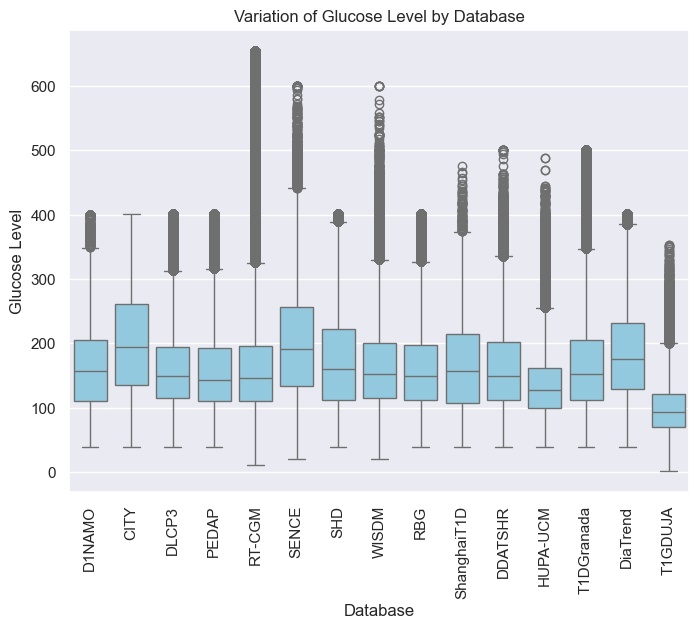

In [ ]:
# creates boxplot of CGM values per separate dataset before outlier removal
plt.figure(figsize=(8, 6))
sns.set_theme(style="darkgrid")
sns.boxplot(x='Database', y='GlucoseCGM', data=combined_main, showfliers=True, color='skyblue')  
plt.xticks(rotation=90)
# adds title and labels
plt.title("Variation of Glucose Level by Database")
plt.suptitle("")  
plt.xlabel("Database")
plt.ylabel("Glucose Level")
plt.show()

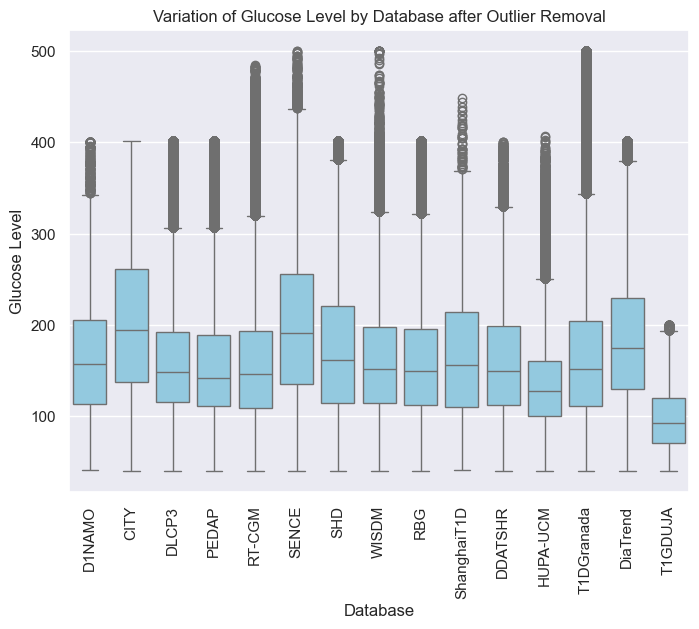

In [ ]:
# creates boxplot of CGM values per separate dataset after outlier removal
plt.figure(figsize=(8, 6))
sns.set_theme(style="darkgrid")
sns.boxplot(x='Database', y='GlucoseCGM', data=data_cleaned, showfliers=True, color='skyblue')  
plt.xticks(rotation=90)
# adds title and labels
plt.title("Variation of Glucose Level by Database after Outlier Removal")
plt.suptitle("")  
plt.xlabel("Database")
plt.ylabel("Glucose Level")
plt.show()

Text(0, 0.5, 'Glucose Level')

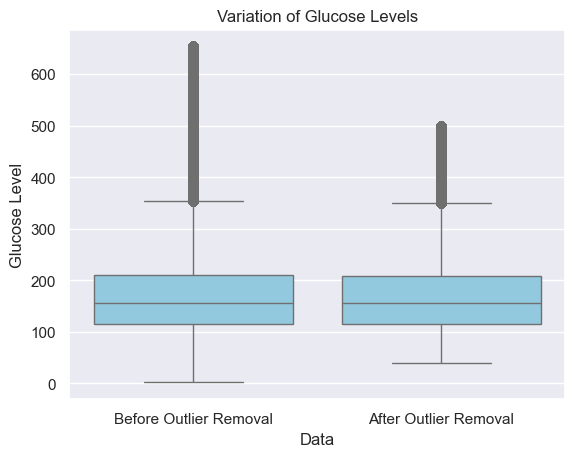

In [ ]:
# prints the boxplots before and after outlier removal considering all datasets in the MDB

# makes a labeled copy of the raw data before removing outliers
combi = combined_main.copy()
combi["Data"] = "Before Outlier Removal"

# makes a labeled copy of the cleaned data after removing outliers
df_int = data_cleaned.copy()
df_int["Data"] = "After Outlier Removal"

# combines both into one df so seaborn can plot them side by side
combined_both = pd.concat([combi, df_int]).reset_index(drop=True)

sns.set_theme(style="darkgrid")
sns.boxplot(
    x="Data",
    y="GlucoseCGM",
    data=combined_both,
    showfliers=True,
    color="skyblue",
)

# adds plot labels 
plt.title("Variation of Glucose Levels")
plt.suptitle("")  
plt.ylabel("Glucose Level")
plt.xlabel("")    

## Missing value imputation

In [ ]:
# linear interpolation is used for gaps which are less than 30 minute (6 consecutive datapoints)
df_interpolated = data_cleaned.copy()
df_interpolated['GlucoseCGM'] = df_interpolated.groupby('PtID')['GlucoseCGM'].transform(
    lambda x: data_preprocessing.gap_limited_interpolation(x, limit=6)
)

# stineman interpolation is used for values between 30 adn 120 minutes
df_interpolated_stine = df_interpolated.groupby("PtID", group_keys=False).apply(lambda x: data_preprocessing.interpolate_stineman_group(x, timestamp = "ts", value = "GlucoseCGM", llimit=6, ulimit=24))
df_interpolated_stine = df_interpolated_stine.sort_index()

: 

In [12]:
# as a comparison, a copy of the cleaned dataset before imputation is made
only_interpolated = data_cleaned.copy()

# missing values of this copy are imputed with linear interpolation for all gaps lengths
only_interpolated['GlucoseCGM'] = only_interpolated.groupby('PtID')['GlucoseCGM'].transform(lambda group: group.interpolate(method='linear'))

/var/folders/t1/sgksm9r9385br4pts_lckj1w0000gn/T/ipykernel_23688/3812106081.py:59: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90)
/var/folders/t1/sgksm9r9385br4pts_lckj1w0000gn/T/ipykernel_23688/3812106081.py:105: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels())


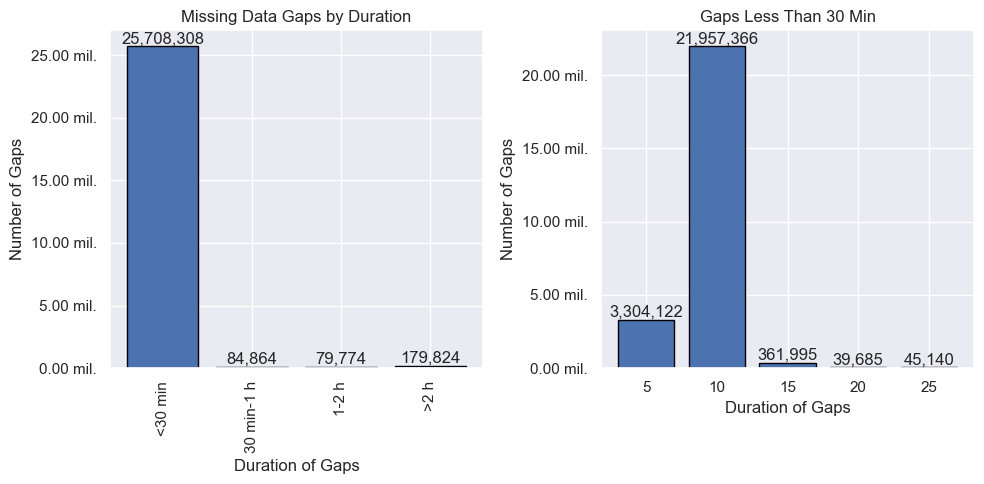

In [ ]:
# plots missing values to explore the data quality
sns.set_theme(style="darkgrid")
# function to show both value and percentage
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        return f"{val} ({pct:.1f}%)"
    return my_autopct

# the dataframe is copied
df_glc_missing = combined_main.copy()
# first, missing blocks are identified 
df_glc_missing["missing"] = df_glc_missing["GlucoseCGM"].isna()

# uses groupby with cumsum to find continuous blocks
df_glc_missing["gap_id"] = (df_glc_missing["missing"] != df_glc_missing["missing"].shift()).cumsum()
# groups by the identified gaps
na_groups = df_glc_missing[df_glc_missing["missing"]].groupby("gap_id").size().reset_index(name="missing_count")
# one row of missing data equals 5 minutes, so the length of gap is multiplied by 5
na_groups["missing_count_time"] = na_groups["missing_count"] * 5

# categorizes durations based on specified bins and labels
bins = [0,30,120,na_groups["missing_count_time"].max()]
labels = [
    "<30 min",
    "30 min-2 h",
    ">2 h"
]
# converts durations to timedelta seconds for binning
duration_bins = pd.cut(na_groups["missing_count_time"], bins=bins, labels=labels, right=False)

# counts number of gaps per duration range
gap_counts = duration_bins.value_counts().sort_index()

# creates the bin groups
na_groups["MissingGroup"] = pd.cut(na_groups["missing_count_time"], bins=bins, labels=labels, right=False)
# filters to only less than 30 minute gaps
count_30_missing = na_groups[na_groups["MissingGroup"] ==  "<30 min"]["missing_count_time"].value_counts()

# plots the missing values count per created group and for the second group of less than 30 minutes in 5 minute intervals
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# plots the barchart of all missing value groups
ax1.bar(gap_counts.index.astype(str), gap_counts.values, edgecolor="black")
ax1.set_title("Missing Data Gaps by Duration")
ax1.set_xlabel("Duration of Gaps")
ax1.set_ylabel("Number of Gaps")

# formatter function
def millions(x, pos):
    return f"{x*1e-6:.2f} mil."

# applyies formatter to axis
ax1.yaxis.set_major_formatter(FuncFormatter(millions))
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90)

# plots the numbers on the bar
    
for bar in ax1.patches:
    height = bar.get_height()
    label = f"{int(height):,}"  
    ax1.text(
        bar.get_x() + bar.get_width() / 2,  
        height,                             
        label,                             
        ha="center", va="bottom"
    )

# plots the missing values distribution less than 30 minutes as a bar chart
count_30_missing = count_30_missing.sort_index()
ax2.bar(count_30_missing.index.astype(str), count_30_missing.values, width=0.8, edgecolor="black")
ax2.set_title("Gaps Less Than 30 Min")
ax2.set_xlabel("Duration of Gaps")
ax2.set_ylabel("Number of Gaps")

for bar in ax2.patches:
    height = bar.get_height()
    label = f"{int(height):,}"  
    ax2.text(
        bar.get_x() + bar.get_width() / 2,  
        height,                            
        label,                              
        ha="center", va="bottom"
    )

# applies formatter to axis 
ax2.yaxis.set_major_formatter(FuncFormatter(millions))
ax2.set_xticklabels(ax2.get_xticklabels())

# layout
plt.tight_layout()
plt.show()

/var/folders/t1/sgksm9r9385br4pts_lckj1w0000gn/T/ipykernel_26374/3707072130.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90)
/var/folders/t1/sgksm9r9385br4pts_lckj1w0000gn/T/ipykernel_26374/3707072130.py:103: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels())


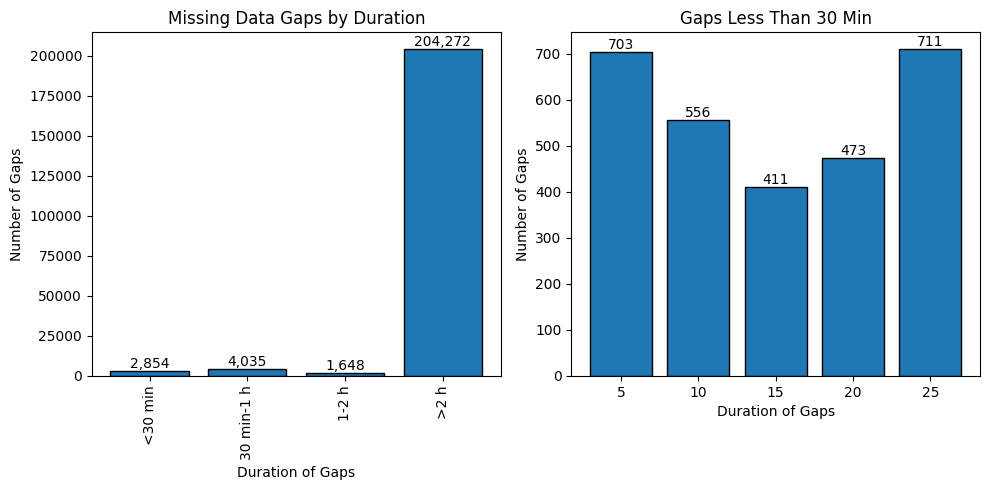

In [ ]:
# plots missing values to explore the data quality after imputation
sns.set_theme(style="darkgrid")

# function to show both value and percentage
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        return f"{val} ({pct:.1f}%)"
    return my_autopct

# the dataframe is copied
df_glc_missing = df_interpolated_stine.copy()
# first, missing blocks are identified 
df_glc_missing["missing"] = df_glc_missing["GlucoseCGM"].isna()

# uses groupby with cumsum to find continuous blocks
df_glc_missing["gap_id"] = (df_glc_missing["missing"] != df_glc_missing["missing"].shift()).cumsum()
# groups by the identified gaps
na_groups = df_glc_missing[df_glc_missing["missing"]].groupby("gap_id").size().reset_index(name="missing_count")
# one row of missing data equals 5 minutes, so the length of gap is multiplied by 5
na_groups["missing_count_time"] = na_groups["missing_count"] * 5

# categorizes durations based on specified bins and labels
bins = [0,30,60,120,na_groups["missing_count_time"].max()]
labels = [
    "<30 min",
    "30 min-1 h",
    "1-2 h",
    ">2 h"
]
# converts durations to timedelta seconds for binning
duration_bins = pd.cut(na_groups["missing_count_time"], bins=bins, labels=labels, right=False)

# counts number of gaps per duration range
gap_counts = duration_bins.value_counts().sort_index()

# creates the bin groups
na_groups["MissingGroup"] = pd.cut(na_groups["missing_count_time"], bins=bins, labels=labels, right=False)
# filters to only less than 30 minute gaps
count_30_missing = na_groups[na_groups["MissingGroup"] ==  "<30 min"]["missing_count_time"].value_counts()

# plots the missing values count per created group and for the second group of less than 30 minutes in 5 minute intervals
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# plots the barchart of all missing value groups
ax1.bar(gap_counts.index.astype(str), gap_counts.values, edgecolor="black")
ax1.set_title("Missing Data Gaps by Duration")
ax1.set_xlabel("Duration of Gaps")
ax1.set_ylabel("Number of Gaps")

# formatter function
def millions(x, pos):
    return f"{x*1e-6:.2f} mil."

# applyies formatter to axis
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90)

# plots the numbers on the bar
for bar in ax1.patches:
    height = bar.get_height()
    label = f"{int(height):,}"  
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        height,                           
        label,                            
        ha="center", va="bottom"
    )

# plots the missing values distribution less than 30 minutes as a bar chart
count_30_missing = count_30_missing.sort_index()
ax2.bar(count_30_missing.index.astype(str), count_30_missing.values, width=0.8, edgecolor="black")
ax2.set_title("Gaps Less Than 30 Min")
ax2.set_xlabel("Duration of Gaps")
ax2.set_ylabel("Number of Gaps")


for bar in ax2.patches:
    height = bar.get_height()
    label = f"{int(height):,}"  
    ax2.text(
        bar.get_x() + bar.get_width() / 2,  
        height,                             
        label,                             
        ha="center", va="bottom"
    )

# applies formatter to axis 
ax2.set_xticklabels(ax2.get_xticklabels())

# layout
plt.tight_layout()
plt.show()

In [ ]:
# this function plots the missing and imputed CGM values for the first gap occurence of the selected subject
def plot_missing_values(data_cleaned, df_interpolated_stine, only_interpolated, subject):

    # takes only rows for the chosen subject (raw / imputed / linear-imputed)
    subset_raw = data_cleaned[data_cleaned["PtID"] == subject]
    subset = df_interpolated_stine[df_interpolated_stine["PtID"] == subject]
    subset_onlyl = only_interpolated[only_interpolated["PtID"] == subject]

    # marks missing values in the raw data
    df = subset_raw.copy()
    df.set_index("ts", inplace=True)
    # is_nan = 1 where GlucoseCGM is NaN, else 0
    is_nan = df["GlucoseCGM"].isna().astype(int)

    # groups consecutive runs of equal is_nan values (run-length encoding)
    df["group"] = (is_nan.diff(1) != 0).cumsum()
    # only keep the NaN runs, then group them by run id
    nan_groups = df[is_nan == 1].groupby("group")

    # finds first missing-value run that's ~1 hour long
    # (13..23 points because CGM is in 5-min sample rate)
    for group_id, group_df in nan_groups:
        if len(group_df) >= 13 and len(group_df) < 24:
            start_time = group_df.index[0]
            end_time = group_df.index[len(group_df) - 1]
            print(f"First 1-hour NaN gap starts at: {start_time}, ends at: {end_time}")
            break
    else:
        print("No 1-hour gap of continuous missing values found.")

    # defines the window around the first gap
    start_date = start_time - timedelta(hours=1)
    end_date = start_time + timedelta(hours=8)

    # slices raw + imputed series to that time window
    raw_week = subset_raw[(subset_raw["ts"] >= start_date) & (subset_raw["ts"] <= end_date)]
    imputed_week = subset[(subset["ts"] >= start_date) & (subset["ts"] <= end_date)]
    linear_imputed_week = subset_onlyl[
        (subset_onlyl["ts"] >= start_date) & (subset_onlyl["ts"] <= end_date)
    ]

    # sets time as index (not strictly needed for plotting, but ok)
    subset_raw.set_index("ts", inplace=True)
    subset.set_index("ts", inplace=True)
    subset_onlyl.set_index("ts", inplace=True)

    # keeps only the imputed values that correspond to NaNs in raw
    df_imputed_masked = imputed_week.copy()
    df_imputed_masked["GlucoseCGM"] = imputed_week["GlucoseCGM"].where(
        raw_week["GlucoseCGM"].isna()
    )

    # same masking for the linear interpolation version
    df_imputed_masked_l = linear_imputed_week.copy()
    df_imputed_masked_l["GlucoseCGM"] = linear_imputed_week["GlucoseCGM"].where(
        raw_week["GlucoseCGM"].isna()
    )

    # makes sure we have datetime columns for plotting
    raw_week["date"] = pd.to_datetime(raw_week["ts"], format="%Y-%m-%d %H:%M:%S")
    df_imputed_masked["date"] = pd.to_datetime(df_imputed_masked["ts"], format="%Y-%m-%d %H:%M:%S")
    df_imputed_masked_l["date"] = pd.to_datetime(
        df_imputed_masked_l["ts"], format="%Y-%m-%d %H:%M:%S"
    )

    # plot raw series + imputed-only overlays
    plt.figure(figsize=(12, 6))
    plt.plot(
        raw_week["date"],
        raw_week["GlucoseCGM"],
        label="Raw Glucose Levels",
        marker="o",
        linestyle="-",
        alpha=0.7,
    )
    plt.plot(
        df_imputed_masked["date"],
        df_imputed_masked["GlucoseCGM"],
        label="Imputed Glucose Levels",
        marker="x",
        linestyle="--",
        alpha=0.7,
    )
    plt.plot(
        df_imputed_masked_l["date"],
        df_imputed_masked_l["GlucoseCGM"],
        label="Linearly Imputed Glucose Levels",
        linestyle="-",
        alpha=0.5,
    )

    plt.title(f"Raw vs Imputed Data of Subject: {subject}")
    plt.xlabel("Date")
    plt.ylabel("Glucose Level")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

First 1-hour NaN gap starts at: 2000-07-13 21:00:00, ends at: 2000-07-13 22:10:00


/var/folders/t1/sgksm9r9385br4pts_lckj1w0000gn/T/ipykernel_9886/416940038.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_week['date'] = pd.to_datetime(raw_week['ts'], format='%Y-%m-%d %H:%M:%S')


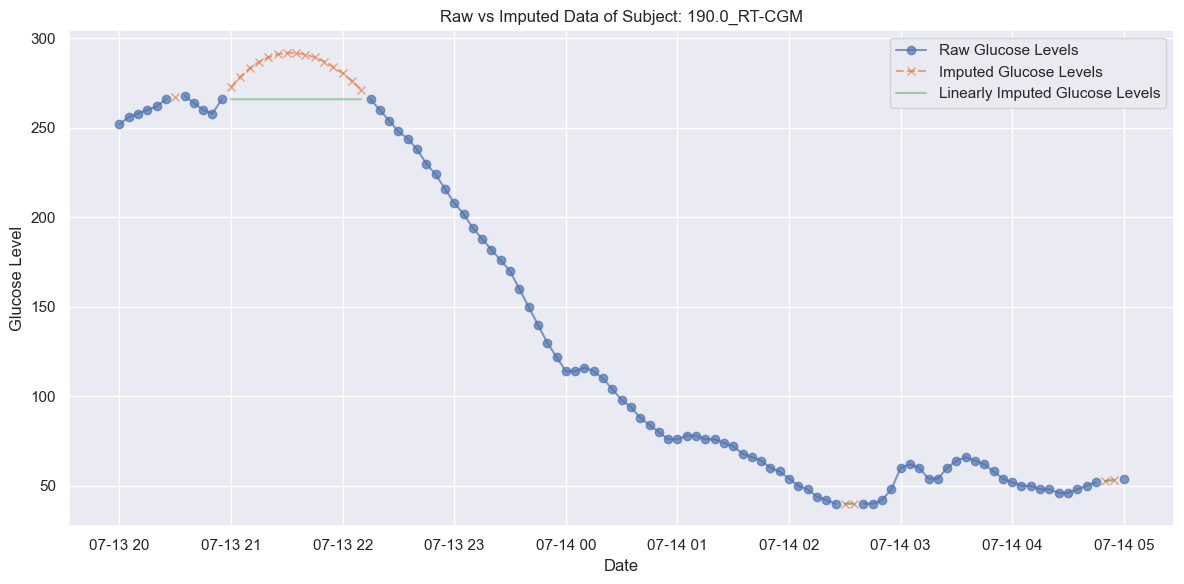

In [13]:
plot_missing_values(data_cleaned, df_interpolated_stine, only_interpolated, "190.0_RT-CGM")

First 1-hour NaN gap starts at: 2000-03-16 04:30:00, ends at: 2000-03-16 05:40:00


/var/folders/t1/sgksm9r9385br4pts_lckj1w0000gn/T/ipykernel_9886/416940038.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_week['date'] = pd.to_datetime(raw_week['ts'], format='%Y-%m-%d %H:%M:%S')


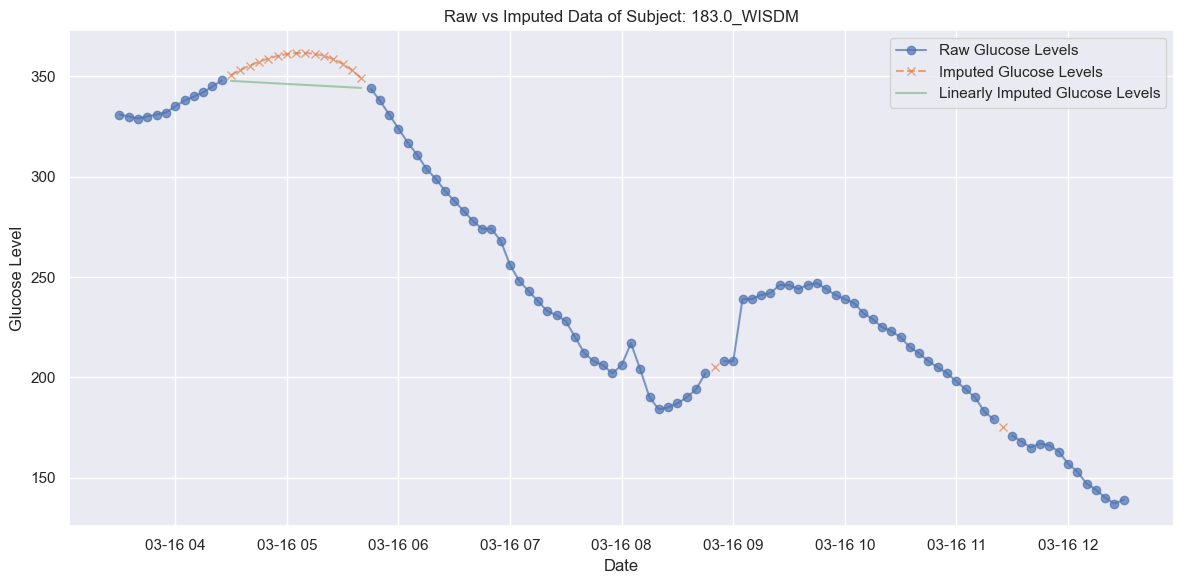

In [14]:
plot_missing_values(data_cleaned, df_interpolated_stine, only_interpolated, "183.0_WISDM")

First 1-hour NaN gap starts at: 2018-02-14 09:25:00, ends at: 2018-02-14 11:00:00


/var/folders/t1/sgksm9r9385br4pts_lckj1w0000gn/T/ipykernel_9886/416940038.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_week['date'] = pd.to_datetime(raw_week['ts'], format='%Y-%m-%d %H:%M:%S')


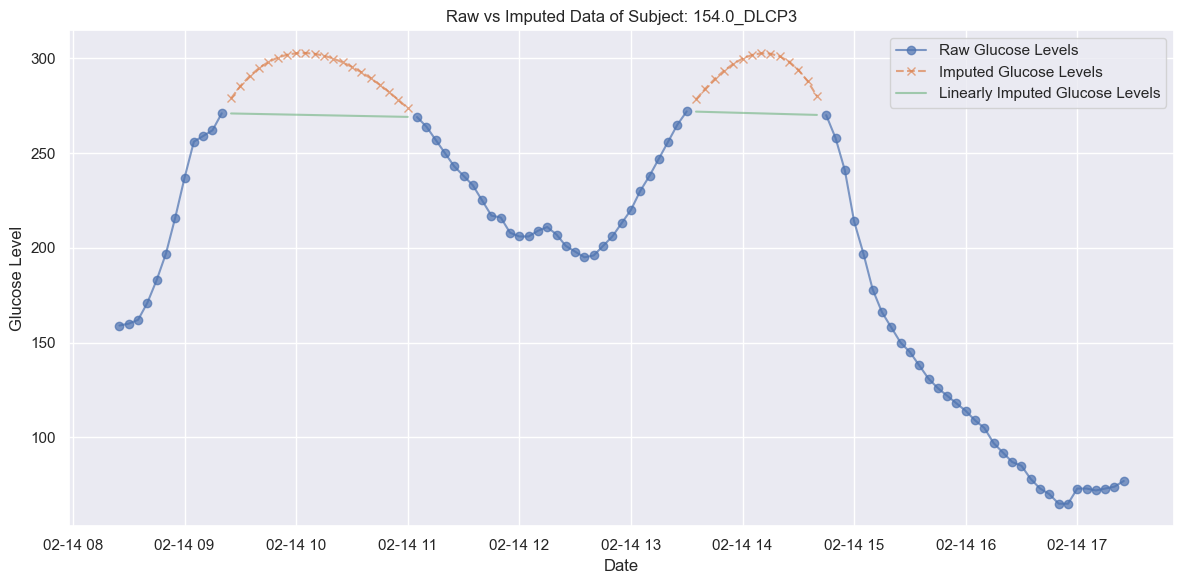

In [15]:
plot_missing_values(data_cleaned, df_interpolated_stine, only_interpolated, "154.0_DLCP3")

First 1-hour NaN gap starts at: 2021-05-10 14:00:00, ends at: 2021-05-10 15:35:00


/var/folders/t1/sgksm9r9385br4pts_lckj1w0000gn/T/ipykernel_9886/416940038.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_week['date'] = pd.to_datetime(raw_week['ts'], format='%Y-%m-%d %H:%M:%S')


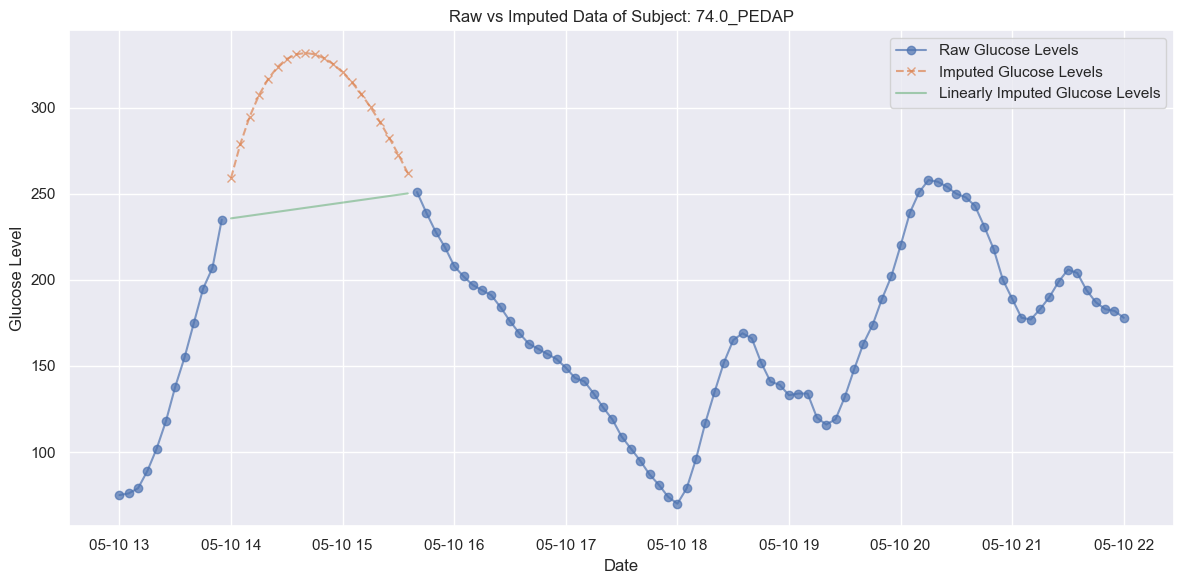

In [16]:
plot_missing_values(data_cleaned, df_interpolated_stine, only_interpolated, "74.0_PEDAP")

## Assign classes and generate time series

In [8]:
# dataset with interpolated values is copied
classes_df = df_interpolated_stine.copy()
# initially all classes are assigned a class -1
classes_df["Class"] = -1
# hypoglycemic values are defined as class 0 with values equal and lower than 70 mg/dL
classes_df.loc[classes_df["GlucoseCGM"] <= 70, "Class"] = 0

# calls the function class_generation to assing classes based on wanted intervals before hypogylcemia for each subject separately
classes_df = classes_df.groupby("PtID", group_keys=False).apply(lambda x: data_preprocessing.class_generation(x,"ts", 5, 15, 1)) # 5-15 min
classes_df = classes_df.groupby("PtID", group_keys=False).apply(lambda x: data_preprocessing.class_generation(x,"ts", 15, 30, 2)) # 15-30 min
classes_df = classes_df.groupby("PtID", group_keys=False).apply(lambda x: data_preprocessing.class_generation(x,"ts", 30, 60, 3))  # 30-60 min
classes_df = classes_df.groupby("PtID", group_keys=False).apply(lambda x: data_preprocessing.class_generation(x,"ts",  60, 125, 4)) # 1-2 h
classes_df.loc[classes_df["Class"] == -1, "Class"] = 5

# sorts the glucose values by patient id and timestamps
df_sorted = classes_df.sort_values(by=['PtID', 'ts'])
# reindexes based on the sorted dataset
df_sorted = df_sorted.reset_index(drop=True)

In [ ]:
# prints the distribution of values per class
df_sorted["Class"].value_counts()

Class
5    218820433
4      6485889
0      6283444
3      3305367
2      1775458
1      1255676
Name: count, dtype: int64

## Normalization

In [10]:
# normalizes data 
df_min_max_scaled = data_preprocessing.normalize_data(df_sorted, 'GlucoseCGM')

## Generate time series sequences

In [11]:
def create_X_Y(df, feature, sample_count= 25, hours = 2, modus = 'h'):

    # generates time series with sliding window approach
    result = df.groupby('PtID').apply(lambda g: data_preprocessing.extract_valid_windows_GLC(g, expected_sample_count = sample_count,
    min_window_duration = np.timedelta64(hours, modus)))

    # filters out None values of subjects with insufficient data
    filtered_result = [item for item in result if item is not None]
    # unpacks the values
    X_data, Y_data = zip(*filtered_result)

    return X_data, Y_data

# calls the function for time series generation with a 30 min input length 
X_data, Y_data = create_X_Y(df_min_max_scaled, "PtID", 7, 30, 'm')

In [13]:
len(X_data)

2495

## FCN model

In [12]:
# ensures reproducability
seed_value= 42  
os.environ["PYTHONHASHSEED"]=str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.compat.v1.set_random_seed(seed_value)

# initializes 5 folds
kfolds = KFold(n_splits=5, shuffle=True, random_state=42)
with open("MDB_5fold_indices.txt", "w", encoding="utf-8") as f:
    for fold, (train_idx, test_idx) in enumerate(kfolds.split(X_data), start=1):
        f.write(f"Fold {fold}\n")
        f.write("Train indices:\n")
        f.write(" ".join(map(str, train_idx)) + "\n")
        f.write("Test indices:\n")
        f.write(" ".join(map(str, test_idx)) + "\n")
        f.write("\n")

In [ ]:
# ensures reproducability
seed_value= 42  
os.environ['PYTHONHASHSEED']=str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.compat.v1.set_random_seed(seed_value)
session_conf = tf.compat.v1.ConfigProto(intra_op_parallelism_threads=1, inter_op_parallelism_threads=1)
sess = tf.compat.v1.Session(graph=tf.compat.v1.get_default_graph(), config=session_conf)
tf.compat.v1.keras.backend.set_session(sess)

# initializes 5 folds for cross validation
kfolds = KFold(n_splits=5, shuffle=True, random_state=42)

count = 0

# empty list for the predicted and actual values
MDB_actual_labels_All_30min_focal_GLC = []
MDB_predicted_labels_fcn_All_30min_focal_GLC = []

# empty lists for the metrics calculated at each fold
lower_CI = []
upper_CI = []
F1_macro = []
Rec_macro = []
Pre_macro = []
PR_AUC_macro = []

F1_class = []
Rec_class = []
Pre_class = []
PR_AUC_class = []
PR_AVG_class = []
PR_AUC_Mac = []
PR_AVG_Mac = []

ECE = []
ECE_class = []

for train_idx, test_idx in kfolds.split(X_data):

    average_precisions = []
    PRauc_scores = []

    print(f"Started for fold {count}")

    train_idx = train_idx[count]
    test_idx = test_idx[count]

    # extracts the selected subjects for training for the X and Y folds
    X_train_fold = [X_data[i] for i in train_idx]
    Y_train_fold = [Y_data[i] for i in train_idx]
    # extracts the selected subjects for testing for the X and Y folds
    X_test_fold = [X_data[i] for i in test_idx]
    Y_test_fold = [Y_data[i] for i in test_idx]

    # flattens the arrays of single subjects into one array of shape (X,25,2)
    X_train_fold = data_preprocessing.flatten_data(X_train_fold, modus = "input", shape_f = 7, dim = 1)
    # flattens the arrays of single subjects into one array of shape (X,1)
    Y_train_fold = data_preprocessing.flatten_data(Y_train_fold, modus = "output", shape_f = 7, dim = 1)

    # flattens the arrays of single subjects into one array of shape (X,25,2)
    X_test_fold = data_preprocessing.flatten_data(X_test_fold, modus = "input", shape_f =7,dim = 1) 
    # flattens the arrays of single subjects into one array of shape (X,1)
    Y_test_fold = data_preprocessing.flatten_data(Y_test_fold, modus = "output",shape_f = 7, dim = 1)

    # encodes Y data to categorical, since focal loss is used
    Y_train_encoded = to_categorical(Y_train_fold)
    Y_test_encoded = to_categorical(Y_test_fold)

    # for class weights 
    Y_test_weights = Y_test_fold.reshape(-1).astype('int32')

    BUFFER_SIZE = len(X_train_fold) 
    BATCH_SIZE = 256

    # reshapes Y_train, val, and test
    Y_train_rs = Y_train_fold.reshape(-1).astype('int32')
    Y_test_rs = Y_test_fold.reshape(-1).astype('int32')

    # converts train, val, and test data into tensors
    X_train_t = tf.convert_to_tensor(X_train_fold, dtype=tf.float32)
    Y_train_t = tf.convert_to_tensor(Y_train_encoded, dtype=tf.int32)

    X_test_t = tf.convert_to_tensor(X_test_fold, dtype=tf.float32)
    Y_test_t = tf.convert_to_tensor(Y_test_encoded, dtype=tf.int32)

    # shuffles train data and applies batch size 
    train_ds_t = tf.data.Dataset.from_tensor_slices((X_train_t, Y_train_t))
    train_ds = train_ds_t.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=1e-4)
    focloss = tf.keras.losses.CategoricalFocalCrossentropy()


    # builds and trains the FCN model
    model_fcn = data_models.build_FCN((X_train_fold.shape[1], X_train_fold.shape[2]), 5) 
    model_fcn.compile(loss=focloss, optimizer=optimizer, metrics=['categorical_accuracy'])
    model_fcn.fit(train_ds, epochs=25, verbose=0)

    sns.set_theme(style="white")
    # evaluates the model and plots the confusion matrix
    predictions_fcn = model_fcn.predict(X_test_t)
    y_pred_fcn = np.argmax(predictions_fcn, axis=1) 
    y_true_labels = np.argmax(Y_test_t, axis=1)
    ConfusionMatrixDisplay.from_predictions(y_true_labels, y_pred_fcn)
    # saves the confusion matrix
    name_img_test = "Images/Confusion_Matrices/MDB_FCN_5FCV_30min_focal_GLC_%i.png" % (count)
    plt.savefig(name_img_test)
    plt.show()

    # saves the model 
    name_fcn = "Models/Quality_Refined_MDB/MDB_FCN_5FCV_30min_FL_GLC_%i.hdf5" % (count)
    model_fcn.save(name_fcn)

    report_fcn = classification_report(y_true_labels, y_pred_fcn, digits=4)
    print(report_fcn)

    # calculates metrics for each fold and saves result in an array for later computation 
    mean_f1, ci_lower, ci_upper = data_models.bootstrap_macro_f1(np.array(Y_test_rs), np.array(y_pred_fcn))

    print(f"Bootstrapped Macro F1: {mean_f1:.4f}")
    print(f"95% CI: ({ci_lower:.4f}, {ci_upper:.4f})")

    lower_CI.append(ci_lower) 
    upper_CI.append(ci_upper)

    f1_score_mac = f1_score(Y_test_rs, y_pred_fcn, average='macro')
    F1_macro.append(f1_score_mac)

    rec_scores_mac = recall_score(Y_test_rs, y_pred_fcn, average='macro')
    Rec_macro.append(rec_scores_mac)

    pre_scores_mac = precision_score(Y_test_rs, y_pred_fcn, average='macro')
    Pre_macro.append(pre_scores_mac)

    f1_scores = f1_score(Y_test_rs, y_pred_fcn, average=None, labels=np.arange(5))
    F1_class.append(f1_scores)

    rec_scores = recall_score(Y_test_rs,y_pred_fcn, average=None, labels=np.arange(5))
    Rec_class.append(rec_scores)

    pre_scores = precision_score(Y_test_rs, y_pred_fcn, average=None, labels=np.arange(5))
    Pre_class.append(pre_scores)

    classes = set(Y_test_rs)
    for n_cl, cl in enumerate(classes):  
            f_pre, f_rec, t = precision_recall_curve(Y_test_t[:, cl], predictions_fcn[:, cl])
            sorted_indices = np.argsort(f_rec)
            pr_auc_scores = auc(f_rec, f_pre)
            ap_score = average_precision_score(Y_test_t[:, cl], predictions_fcn[:, cl])
            average_precisions.append(ap_score)
            PRauc_scores.append(pr_auc_scores)

    PR_AVG_class.append(average_precisions)
    PR_AVG_scores_mac = np.mean(average_precisions)
    PR_AVG_Mac.append(PR_AVG_scores_mac)

    PR_AUC_class.append(PRauc_scores)
    PRAUC_mean = np.mean(PRauc_scores)
    PR_AUC_Mac.append(PRAUC_mean)

    print(f"Class PR AUC: {PR_AUC_class}")
    print(f"Mac PR AUC: ({PR_AUC_Mac})")

    ece_score = data_models.expected_calibration_error_batched(predictions_fcn,Y_test_fold, M=10, batch_size=100_000)
    print(f"ECE: {ece_score:.4f}")
    ECE.append(ece_score)

    ece_per_class = data_models.compute_ece_per_class(predictions_fcn,Y_test_fold, M=10)      
    print(ece_per_class)  
    ECE_class.append(ece_per_class)

    count = count + 1


# concats preditions and true values of all folds to plot one confusion matrix considering the performance of all folds
print("Report for MDB FCN 5FCV 30min FL GLC")
y_pred_fcn = np.argmax(flatten(MDB_predicted_labels_fcn_All_30min_focal_GLC), axis=1) 
y_true_labels = np.argmax(flatten(MDB_actual_labels_All_30min_focal_GLC), axis=1)
ConfusionMatrixDisplay.from_predictions(y_true_labels, y_pred_fcn)
plt.show()

# prints classification report fort all folds
print(classification_report(y_true_labels, y_pred_fcn, digits=4))

# Saves reports of all folds and macro averages into txt file
with open("MDB_FCN_5FCV_30min_FL_GLC.txt", "w") as f:

    f.write("Lower Confidence Intervals:")
    f.write(", ".join([f"{score:.4f}" for score in lower_CI]) + "\n")
    f.write(f"Mean Lower Confidence Intervals: {np.mean(lower_CI):.4f}" +"\n")
    f.write(f"STD Lower Confidence Intervals: {np.std(lower_CI):.4f}" +"\n\n")

    f.write("Upper Confidence Intervals:")
    f.write(", ".join([f"{score:.4f}" for score in upper_CI]) + "\n")
    f.write(f"Mean Upper Confidence Intervals: {np.mean(upper_CI):.4f}" +"\n")
    f.write(f"STD Upper Confidence Intervals: {np.std(upper_CI):.4f}" +"\n\n")

    f.write("Macro F1 Measure:")
    f.write(", ".join([f"{score:.4f}" for score in F1_macro]) + "\n")
    f.write(f"Mean Macro F1 Measure: {np.mean(F1_macro):.4f}" +"\n")
    f.write(f"STD Macro F1 Measure: {np.std(F1_macro):.4f}" +"\n\n")

    f.write("Macro Recall:")
    f.write(", ".join([f"{score:.4f}" for score in Rec_macro]) + "\n")
    f.write(f"Mean Macro Recall: {np.mean(Rec_macro):.4f}" +"\n")
    f.write(f"STD Macro Recall: {np.std(Rec_macro):.4f}" +"\n\n")

    f.write("Macro Precision:")
    f.write(", ".join([f"{score:.4f}" for score in Pre_macro]) + "\n")
    f.write(f"Mean Macro Precision: {np.mean(Pre_macro):.4f}" +"\n")
    f.write(f"STD Macro Precision: {np.std(Pre_macro):.4f}" +"\n\n")

    f.write("Macro PR AUC:")
    f.write(", ".join([f"{score:.4f}" for score in PR_AUC_Mac]) + "\n")
    f.write(f"Mean Macro PR AUC: {np.mean(PR_AUC_Mac):.4f}" +"\n")
    f.write(f"STD Macro PR AUC: {np.std(PR_AUC_Mac):.4f}" +"\n\n")

    f.write("Macro AVG PR:")
    f.write(", ".join([f"{score:.4f}" for score in PR_AVG_Mac]) + "\n")
    f.write(f"Mean Macro AVG PR: {np.mean(PR_AVG_Mac):.4f}" +"\n")
    f.write(f"STD Macro AVG PR: {np.std(PR_AVG_Mac):.4f}" +"\n\n")

    f.write("F1 Measure per Class:")
    f.write(", ".join([f"{score}" for score in F1_class]) + "\n\n")
   
    f.write("Recall per Class:")
    f.write(", ".join([f"{score}" for score in Rec_class]) + "\n\n")

    f.write("Precision per Class:")
    f.write(", ".join([f"{score}" for score in Pre_class]) + "\n\n")

    f.write("PR AUC per Class:")
    f.write(", ".join([f"{score}" for score in PR_AUC_class]) + "\n\n")

    f.write("AVG PR per Class:")
    f.write(", ".join([f"{score}" for score in PR_AVG_class]) + "\n\n")

    f.write("Expected Calibration Error:")
    f.write(", ".join([f"{score}" for score in ECE]) + "\n\n")

## Metrics

In [ ]:
# prints the macro metrics per fold and per class

file= 'Reports/MDB_FCN_5FCV_30min_FL_GLC.txt'


# general regex patterns to locate metric blocks
patterns = {
    "F1 Measure": r"F1 Measure per Class:\s*((?:\[[^\]]+\],?\s*)+)",
    "Recall": r"Recall per Class:\s*((?:\[[^\]]+\],?\s*)+)",
    "Precision": r"Precision per Class:\s*((?:\[[^\]]+\],?\s*)+)",
    "PR AUC": r"PR AUC per Class:\s*((?:\[[^\]]+\],?\s*)+)"
}

# helper function to extract numeric arrays
def extract_arrays(block_text):
    """Extracts all bracketed numeric arrays from a text block."""
    arrays = re.findall(r"\[([^\]]+)\]", block_text)
    parsed = [np.fromstring(a.replace(",", " "), sep=" ") for a in arrays]
    return np.array(parsed)

with open(file, "r") as f:
    text = f.read()

for metric_name, pattern in patterns.items():
    match = re.search(pattern, text)
    if not match:
        continue
    arrays = extract_arrays(match.group(1))
    if arrays.size == 0:
        continue

    if metric_name == "F1 Measure":
        f1_all = arrays
    elif metric_name == "Recall":
        recall_all = arrays
    elif metric_name == "Precision":
        precision_all = arrays
    elif metric_name == "PR AUC":
        pr_auc_all = arrays

# computes summary stats
def summarize(metric, name):
    if metric.size == 0:
        print(f"\n{name}: No data found.")
        return
    mean_per_class = np.mean(metric, axis=0)
    std_per_class = np.std(metric, axis=0)
    macro_mean = np.mean(mean_per_class)
    macro_std = np.std(mean_per_class)

    print(f"\n{name} Results:")
    print(f"Mean per Class: {np.round(mean_per_class, 4)}")
    print(f"Std per Class:  {np.round(std_per_class, 4)}")
    print(f"Macro Mean: {macro_mean:.4f}, Macro Std: {macro_std:.4f}")

# summarizes all metrics
summarize(f1_all, "F1 Measure")
summarize(recall_all, "Recall")
summarize(precision_all, "Precision")
summarize(pr_auc_all, "PR AUC")


F1 Measure Results:
Mean per Class: [0.9985 0.7759 0.5383 0.4322 0.785 ]
Std per Class:  [0.001  0.0095 0.012  0.0106 0.0026]
Macro Mean: 0.7059, Macro Std: 0.1999

Recall Results:
Mean per Class: [0.9989 0.808  0.5362 0.3797 0.8284]
Std per Class:  [0.0021 0.012  0.0223 0.0194 0.0136]
Macro Mean: 0.7103, Macro Std: 0.2220

Precision Results:
Mean per Class: [0.998  0.7469 0.5411 0.5026 0.7461]
Std per Class:  [0.0019 0.0244 0.0136 0.0077 0.0082]
Macro Mean: 0.7069, Macro Std: 0.1773

PR AUC Results:
Mean per Class: [1.     0.8598 0.5735 0.4627 0.8529]
Std per Class:  [0.     0.0108 0.0127 0.0087 0.0022]
Macro Mean: 0.7498, Macro Std: 0.1994
